#**คาดการณ์ราคาเฉลี่ยข้าวเปลือกในตลาดท้องถิ่น**

In [6]:
!pip install pmdarima


In [10]:
!pip uninstall pmdarima -y
!pip install pmdarima

Found existing installation: pmdarima 2.0.4
Uninstalling pmdarima-2.0.4:
  Successfully uninstalled pmdarima-2.0.4
  Using cached pmdarima-2.0.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl.metadata (7.8 kB)
Using cached pmdarima-2.0.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl (2.3 MB)


In [15]:
!pip install --upgrade --force-reinstall numpy==1.26.4 pmdarima


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.1 MB/s eta 0:00:00
  Using cached pmdarima-2.0.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl.metadata (7.8 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached cython-3.1.4-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (5.0 kB)
  Using cached pandas-2.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (91 kB)
  Using cached scikit_learn-1.7.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached scipy-1.16.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (62 kB)
  Using cached statsmodels-0.14.5-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (9.5 kB)
  Using cached urllib3-2.5.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached pac

##นำเข้าไลบรารี

In [1]:
from pmdarima import auto_arima

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

In [4]:
# time series / tests / model
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
# metrics
from sklearn.metrics import mean_squared_error

# หากติดตั้ง pmdarima แล้ว สามารถใช้ auto_arima (แนะนำ)
try:
    from pmdarima import auto_arima
    HAVE_PMD = True
except:
    HAVE_PMD = False

##โหลดไฟล์

In [6]:
input_path = "/content/drive/MyDrive/Colab data science/project_058/rice_price_dataset.csv"  # เปลี่ยนเป็น path ของคุณ

# โหลด
df = pd.read_csv(input_path, parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df = df[["Year","Month","Date","Price"]].set_index("Date")
print("Loaded:", df.shape)
display(df.head())

Loaded: (200, 3)


,Year,Month,Price
Date,,,
2015-01-01,2015,1,8520
2015-02-01,2015,2,8508
2015-03-01,2015,3,8397
2015-04-01,2015,4,8802
2015-05-01,2015,5,8634


##ตรวจสอบข้อมูล + EDA เบื้องต้น

,Price
count,200.000000
mean,10013.930000
std,915.538392
min,8102.000000
25%,9238.250000
50%,9997.500000
75%,10805.500000
max,11811.000000


Missing values: {'Year': 0, 'Month': 0, 'Price': 0}


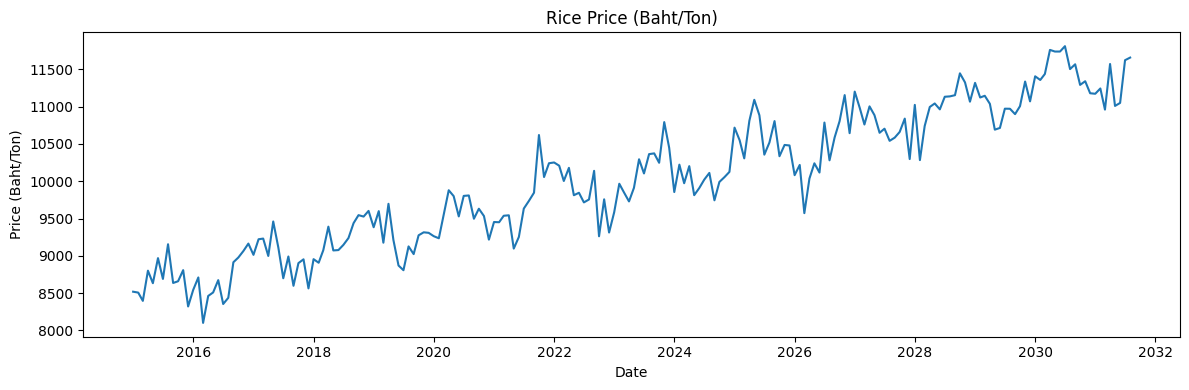

In [7]:
# สถิติพื้นฐาน
display(df["Price"].describe())

# Missing check
print("Missing values:", df.isna().sum().to_dict())

# Plot time series
plt.figure(figsize=(12,4))
plt.plot(df.index, df["Price"])
plt.title("Rice Price (Baht/Ton)")
plt.xlabel("Date")
plt.ylabel("Price (Baht/Ton)")
plt.tight_layout()
plt.show()


##Stationarity tests (ADF + KPSS)

In [8]:
from statsmodels.tsa.stattools import adfuller, kpss

def adf_test(series, name="series"):
    r = adfuller(series, autolag='AIC')
    print(f"ADF {name} -> p-value: {r[1]:.4f}, Test stat: {r[0]:.4f}")

def kpss_test(series, name="series"):
    statistic, p_value, lags, crit = kpss(series, regression='c', nlags="auto")
    print(f"KPSS {name} -> p-value: {p_value:.4f}, Test stat: {statistic:.4f}")

print("ADF test:")
adf_test(df["Price"], "Price")
print("\nKPSS test:")
kpss_test(df["Price"], "Price")

# ถ้าต้องการ differencing อัตโนมัติ (ตัวอย่าง 1st diff)
df_diff = df["Price"].diff().dropna()
print("\nAfter 1st difference ADF/KPSS:")
adf_test(df_diff, "Price_diff")
kpss_test(df_diff, "Price_diff")


ADF test:
ADF Price -> p-value: 0.9122, Test stat: -0.3874

KPSS test:
KPSS Price -> p-value: 0.0100, Test stat: 2.0282

After 1st difference ADF/KPSS:
ADF Price_diff -> p-value: 0.0000, Test stat: -9.5212
KPSS Price_diff -> p-value: 0.1000, Test stat: 0.0127


/tmp/ipython-input-1298122764.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic, p_value, lags, crit = kpss(series, regression='c', nlags="auto")
/tmp/ipython-input-1298122764.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, lags, crit = kpss(series, regression='c', nlags="auto")


##ACF / PACF (ช่วยเลือก p, q)
ในเซลล์นี้ ใช้สร้างกราฟสองประเภทที่สำคัญในการวิเคราะห์ข้อมูลอนุกรมเวลา (time series) คือ ACF และ PACF เพื่อช่วยในการเลือกค่า p และ q ในโมเดล ARIMA

###**ACF (Autocorrelation Function):**
 กราฟนี้แสดงค่าสหสัมพันธ์ระหว่างข้อมูล ณ เวลาปัจจุบันกับข้อมูลในอดีต (lags) ที่แตกต่างกัน ถ้าจุดในกราฟ ACF ค่อยๆ ลดลงหรือตัดแกน x อย่างรวดเร็ว แสดงว่าข้อมูลมีความสัมพันธ์กับค่าในอดีตไม่มากนัก หรือค่าในอดีตที่ห่างออกไปมีความสำคัญน้อยลง     
###**PACF (Partial Autocorrelation Function):**   
  ข้อความตัวเอียงกราฟนี้แสดงค่าสหสัมพันธ์ระหว่างข้อมูล ณ เวลาปัจจุบันกับข้อมูลในอดีต (lags) หลังจากที่หักผลกระทบของค่าระหว่างกลางออกไปแล้ว กราฟนี้มีประโยชน์ในการระบุ "อันดับ" ของกระบวนการ AR (p) ในโมเดล ARIMA

###**วิธีดูกราฟ:**
###ACF: ดูว่าจุดแรกที่ตัดผ่านเส้นขอบความเชื่อมั่น (เส้นประสีฟ้า)
หรือลดลงอย่างมีนัยสำคัญอยู่ที่ Lag เท่าไหร่ ซึ่งอาจบ่งบอกถึงอันดับของกระบวนการ MA (q)
###PACF: ดูว่าจุดแรกที่ตัดผ่านเส้นขอบความเชื่อมั่น (เส้นประสีฟ้า)
หรือลดลงอย่างมีนัยสำคัญอยู่ที่ Lag เท่าไหร่ ซึ่งอาจบ่งบอกถึงอันดับของกระบวนการ AR (p)

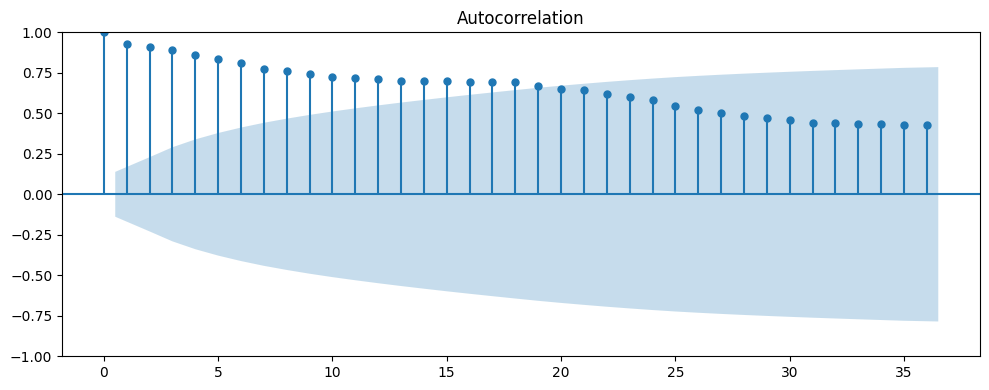

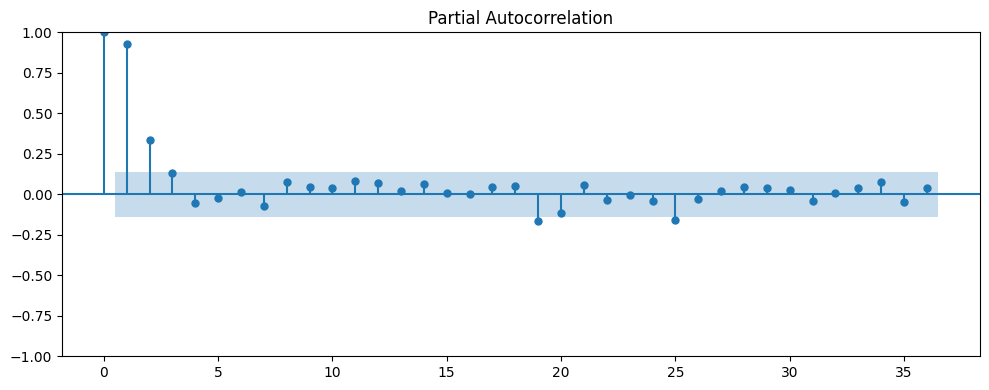

In [9]:
plt.figure(figsize=(10,4))
plot_acf(df["Price"], lags=36, ax=plt.gca())
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(df["Price"], lags=36, ax=plt.gca(), method='ywm')
plt.tight_layout()
plt.show()


##แบ่ง train/test

In [10]:
# ปรับได้ตามต้องการ — ที่นี่ใช้ 12 เดือนสุดท้ายเป็น test
test_months = 12
train = df.iloc[:-test_months].copy()
test = df.iloc[-test_months:].copy()
print("Train:", train.index.min(), "to", train.index.max())
print("Test:", test.index.min(), "to", test.index.max())


Train: 2015-01-01 00:00:00 to 2030-08-01 00:00:00
Test: 2030-09-01 00:00:00 to 2031-08-01 00:00:00


##ใช้ auto_arima เพื่อหา order (เร็วที่สุด ถ้ามี pmdarima)

In [11]:
if HAVE_PMD:
    stepwise_model = auto_arima(
        train["Price"],
        start_p=0, start_q=0,
        max_p=3, max_q=3, m=12,
        start_P=0, seasonal=True, d=None, D=1,
        trace=True, error_action='ignore', suppress_warnings=True,
        stepwise=True, n_jobs=1
    )
    print("auto_arima best order:", stepwise_model.order, "seasonal_order:", stepwise_model.seasonal_order)
    order = stepwise_model.order
    seasonal_order = stepwise_model.seasonal_order
else:
    print("pmdarima not installed — use manual or default params.")
    order = (1,1,1)
    seasonal_order = (1,1,1,12)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=inf, Time=1.06 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=2697.965, Time=0.03 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=2556.113, Time=0.62 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(3,0,2)(2,1,1)[12] intercept   : AIC=inf, Time=4.85 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,0,2)(2,1,1)[12] intercept   : AIC=inf, Time=3.17 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,0,1)(2,1,1)[12]             : AIC=2532.676, Time=4.96 sec

Best model:  ARIMA(3,0,1)(2,1,1)[12] intercept
Total fit time: 62.434 seconds
auto_arima best order: (3, 0, 1) seasonal_order: (2, 1, 1, 12)


##Fit SARIMAX (train) และ forecast

In [12]:
model = SARIMAX(train["Price"],
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False)
res = model.fit(disp=False)
print(res.summary())

# Forecast for test period
n_forecast = len(test)
pred = res.get_forecast(steps=n_forecast)
pred_mean = pred.predicted_mean
pred_conf = pred.conf_int()

# align index
pred_mean.index = test.index
pred_conf.index = test.index


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              Price   No. Observations:                  188
Model:             SARIMAX(3, 0, 1)x(2, 1, 1, 12)   Log Likelihood               -1046.730
Date:                            Mon, 22 Sep 2025   AIC                           2109.460
Time:                                    08:51:10   BIC                           2133.492
Sample:                                01-01-2015   HQIC                          2119.224
                                     - 08-01-2030                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6683      0.326      2.050      0.040       0.029       1.307
ar.L2          0.1761      0.185   

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


RMSE: 381.09, MAPE: 3.02%


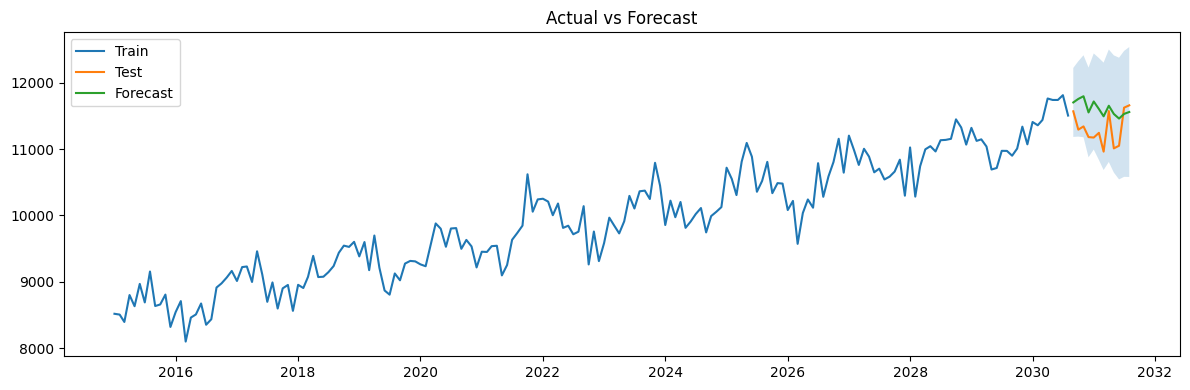

In [13]:
from sklearn.metrics import mean_squared_error

def mape(actual, pred):
    actual_safe = np.where(actual == 0, 1e-8, actual)
    return np.mean(np.abs((actual - pred) / actual_safe)) * 100

rmse = np.sqrt(mean_squared_error(test["Price"], pred_mean))
mape_val = mape(test["Price"].values, pred_mean.values)
print(f"RMSE: {rmse:.2f}, MAPE: {mape_val:.2f}%")

# plot
plt.figure(figsize=(12,4))
plt.plot(train.index, train["Price"], label="Train")
plt.plot(test.index, test["Price"], label="Test")
plt.plot(pred_mean.index, pred_mean, label="Forecast")
plt.fill_between(pred_conf.index, pred_conf.iloc[:,0], pred_conf.iloc[:,1], alpha=0.2)
plt.legend()
plt.title("Actual vs Forecast")
plt.tight_layout()
plt.show()


##บันทึกผลลัพธ์ (CSV/Excel) และบันทึกโมเดล

In [14]:
# ผลลัพธ์ forecast + CI
results_df = pd.DataFrame({
    "Date": test.index,
    "Actual": test["Price"].values,
    "Forecast": pred_mean.values,
    "Lower_CI": pred_conf.iloc[:,0].values,
    "Upper_CI": pred_conf.iloc[:,1].values
}).set_index("Date")

results_df.to_csv("rice_forecast_results.csv")
results_df.to_excel("rice_forecast_results.xlsx")
print("Saved rice_forecast_results.csv and .xlsx in working dir")

# Save model (pickle)
import pickle
with open("sarimax_model.pkl", "wb") as f:
    pickle.dump(res, f)
print("Saved sarimax_model.pkl")
display(results_df)


Saved rice_forecast_results.csv and .xlsx in working dir
Saved sarimax_model.pkl


,Actual,Forecast,Lower_CI,Upper_CI
Date,,,,
2030-09-01,11568,11701.817580,11182.444246,12221.190914
2030-10-01,11292,11754.458743,11187.454211,12321.463275
2030-11-01,11341,11795.020637,11177.943782,12412.097492
2030-12-01,11180,11551.445869,10875.710554,12227.181185
2031-01-01,11173,11716.059435,10992.492143,12439.626728
2031-02-01,11244,11602.378648,10835.050501,12369.706794
2031-03-01,10961,11492.632079,10684.126829,12301.137330
2031-04-01,11572,11651.879746,10805.289769,12498.469724
2031-05-01,11010,11528.070328,10645.777493,12410.363162
